In [2]:
import os
import sys

from matplotlib import ticker

sys.path.append(os.path.join(os.path.dirname(os.getcwd())))
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "src"))

In [3]:
import mne
import mne_rsa

import pandas as pd
import numpy as np

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr

from scipy.stats import spearmanr, zscore
from mne.stats import spatio_temporal_cluster_1samp_test, combine_adjacency

import pathlib
from src.word_level_hidden_states import word_level_hidden_state
from src.tokenizer_utils import load_tokenizer

import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science'])
%matplotlib inline
%config InlineBackend.figure_format='retina'

from tqdm import tqdm

Загрузка описаний событий

In [4]:
events_description_df = pd.read_csv("/Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/hf_datasets/events_description.csv")

def map_congruence_conditions(condition: str):
    condition = condition.lower()
    if condition == "congruent":
        return "normal"
    elif condition == "semantically incongruent":
        return "semantics"
    elif condition == "grammatically incongruent":
        return "grammar"
    elif condition == "semantically-grammatically incongruent":
        return "semantics_grammar"
    else:
        raise ValueError("Unknown condition")

events_description_df["target"] = events_description_df["congruence_condition"].apply(map_congruence_conditions)
events_description_df["sentence_structure"] = events_description_df["sentence_structure"].apply(lambda x: x.replace("Adjective", "Adj").replace("Genitive", "Gen"))

events_description_df = events_description_df[["name", "sentence_structure", "target"]]
events_description_df = events_description_df.rename(columns={"sentence_structure": "structure", "name": "event_name"})

events_description_df

,event_name,structure,target
0,Stimulus/S 1_1,Subject - Verb - Object,normal
1,Stimulus/S 1_2,Subject - Verb - Adj - Object,normal
2,Stimulus/S 1_3,Subject - Verb - Object - Gen,normal
3,Stimulus/S 2_1,Subject - Verb - Object,semantics
4,Stimulus/S 2_2,Subject - Verb - Adj - Object,semantics
5,Stimulus/S 2_3,Subject - Verb - Object - Gen,semantics
6,Stimulus/S 3_1,Subject - Verb - Object,grammar
7,Stimulus/S 3_2,Subject - Verb - Adj - Object,grammar
8,Stimulus/S 3_3,Subject - Verb - Object - Gen,grammar
9,Stimulus/S 4_1,Subject - Verb - Object,semantics_grammar


Загрузка ЭЭГ эпох

In [5]:
epochs_dict: dict[str, mne.Epochs] = {}

for file_name in os.listdir("../hf_datasets/eeg"):
    if file_name.endswith(".fif"):
        epochs = mne.read_epochs(os.path.join("../hf_datasets/eeg", file_name))
        epochs = epochs.apply_baseline((-0.4, 0.0))
        epochs._data *= -1
        epochs = epochs.crop(tmin=0.0, tmax=0.8)
        epochs_dict[file_name.split("_")[0]] = epochs

print(f"Загружено {len(epochs_dict.keys())} эпох")

Reading /Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/notebooks/../hf_datasets/eeg/p2_epochs.fif ...
    Found the data of interest:
        t =    -400.00 ...     800.00 ms
        0 CTF compensation matrices available


/var/folders/88/rz9pfrnd34q32tv5679ygvyh0000gn/T/ipykernel_58804/820323075.py:5: RuntimeWarning: This filename (../hf_datasets/eeg/p2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(os.path.join("../hf_datasets/eeg", file_name))


Not setting metadata
591 matching events found
No baseline correction applied
0 projection items activated
Applying baseline correction (mode: mean)
Reading /Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/notebooks/../hf_datasets/eeg/p12_epochs.fif ...
    Found the data of interest:
        t =    -400.00 ...     800.00 ms
        0 CTF compensation matrices available
Not setting metadata
591 matching events found
No baseline correction applied
0 projection items activated
Applying baseline correction (mode: mean)


/var/folders/88/rz9pfrnd34q32tv5679ygvyh0000gn/T/ipykernel_58804/820323075.py:5: RuntimeWarning: This filename (../hf_datasets/eeg/p12_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(os.path.join("../hf_datasets/eeg", file_name))


Reading /Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/notebooks/../hf_datasets/eeg/p17_epochs.fif ...
    Found the data of interest:
        t =    -400.00 ...     800.00 ms
        0 CTF compensation matrices available


...

Reading /Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/notebooks/../hf_datasets/eeg/p1_epochs.fif ...
    Found the data of interest:
        t =    -400.00 ...     800.00 ms
        0 CTF compensation matrices available


/var/folders/88/rz9pfrnd34q32tv5679ygvyh0000gn/T/ipykernel_58804/820323075.py:5: RuntimeWarning: This filename (../hf_datasets/eeg/p1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(os.path.join("../hf_datasets/eeg", file_name))


Not setting metadata
600 matching events found
No baseline correction applied
0 projection items activated
Applying baseline correction (mode: mean)
Reading /Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/notebooks/../hf_datasets/eeg/p11_epochs.fif ...
    Found the data of interest:
        t =    -400.00 ...     800.00 ms
        0 CTF compensation matrices available


/var/folders/88/rz9pfrnd34q32tv5679ygvyh0000gn/T/ipykernel_58804/820323075.py:5: RuntimeWarning: This filename (../hf_datasets/eeg/p11_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(os.path.join("../hf_datasets/eeg", file_name))


Not setting metadata
600 matching events found
No baseline correction applied
0 projection items activated
Applying baseline correction (mode: mean)
Загружено 21 эпох


Подсчет событий для каждого субъекта

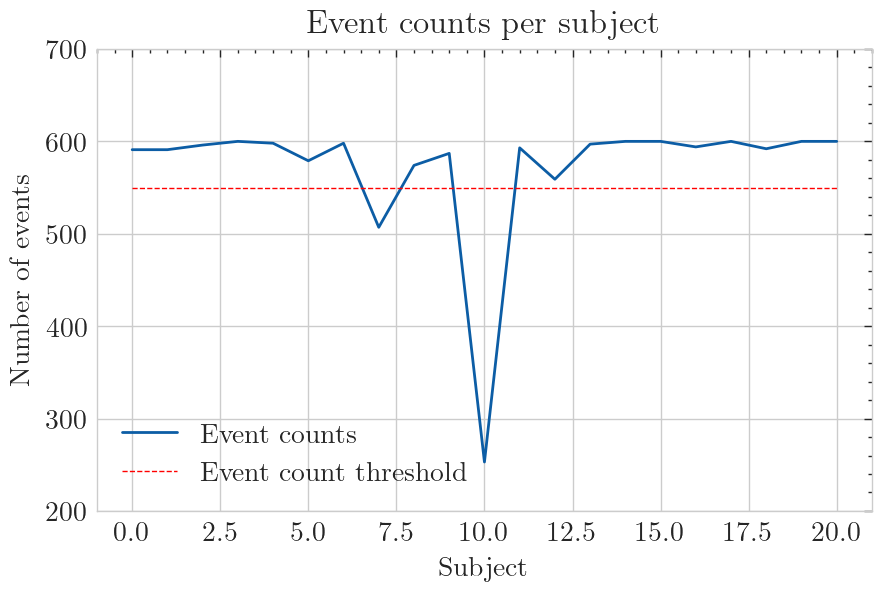

In [6]:
event_counts = []
for epochs in epochs_dict.values():
    event_counts.append(len(epochs))

plt.figure(figsize=[5, 3])
plt.plot(event_counts, label="Event counts")
plt.grid(True)
plt.title("Event counts per subject")
plt.ylabel("Number of events")
plt.xlabel("Subject")
plt.ylim((200, 700))
plt.hlines(550, xmin=0, xmax=20, linestyles="dashed", linewidth=0.5, colors="red", label="Event count threshold")
plt.legend()
plt.show()

In [8]:
threshold = 500
filtered_epoch_dict: dict[str, mne.Epochs] = {}
for k, epochs in epochs_dict.items():
    if len(epochs) > threshold:
        filtered_epoch_dict[k] = epochs

print(f"Отобрано {len(filtered_epoch_dict)} испытуемых")

erps_dict: dict[str, list[mne.Evoked]] = {}
for k, epochs in filtered_epoch_dict.items():
    erps_dict[k] = epochs.average(by_event_type=True)

print("Усреднение по событиям завершено")

conditions = [averaged.comment for averaged in erps_dict["p1"]]
print(f"Условия {conditions}")

Отобрано 20 испытуемых
Усреднение по событиям завершено
Условия ['Stimulus/S  1_1', 'Stimulus/S  1_2', 'Stimulus/S  1_3', 'Stimulus/S  2_1', 'Stimulus/S  2_2', 'Stimulus/S  2_3', 'Stimulus/S  3_1', 'Stimulus/S  3_2', 'Stimulus/S  3_3', 'Stimulus/S  4_1', 'Stimulus/S  4_2', 'Stimulus/S  4_3']


### RSA

In [9]:
def make_windows(times, win_len=0.02, win_step=0.01):
    tmin, tmax = times[0], times[-1]
    starts = np.arange(tmin, tmax - win_len, win_step)
    windows = [(s, s + win_len) for s in starts]
    return windows

def compute_eeg_rdms_mne_rsa(
    erps_dict: dict[str, list[mne.Evoked]],
    win_len: float = 0.02,
    win_step: float = 0.01,
    picks: list[str] | None = None,
):

    subj_ids = list(erps_dict.keys())

    times = erps_dict[subj_ids[0]][0].times
    windows = make_windows(times, win_len, win_step)
    win_times = np.array(windows)

    rdms = []

    for subj in subj_ids:
        evokeds = erps_dict[subj]

        if picks is not None:
            evokeds = [e.copy().pick(picks) for e in evokeds]


        data = np.stack([e.data for e in evokeds], axis=0)

        subj_rdms = []

        for tmin, tmax in windows:

            idx = np.where((times >= tmin) & (times <= tmax))[0]
            Xw = data[:, :, idx].mean(axis=2)


            Xw = (Xw - Xw.mean(axis=0)) / Xw.std(axis=0)

            rdm = mne_rsa.compute_rdm(
                Xw,
                metric="correlation",
            )
            subj_rdms.append(rdm)
        rdms.append(subj_rdms)
    rdms = np.asarray(rdms)
    return rdms, win_times, subj_ids


rdms_eeg, win_times, subj_ids = compute_eeg_rdms_mne_rsa(erps_dict)



ЗЗагрузка скрытых состояний модели

In [10]:
model_hidden_state_folders = [
    (
        "ai-sage/GigaChat3-10B-A1.8B-base",
        "/Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/src/results/ai-sage_GigaChat3-10B-A1.8B-base"
    ),
    (
        "Qwen/Qwen3-8B",
        "/Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/src/results/Qwen_Qwen3-8B"
    ),
    (
        "google/gemma-3-12b-pt",
        "/Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/src/results/google_gemma-3-12b-pt"
    ),
    (
        "meta-llama/Meta-Llama-3-8B",
        "/Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/src/results/meta-llama_Meta-Llama-3-8B"
    ),
]

model_rdm_dict: dict[str, np.ndarray] = {}
stimuli_df = pd.read_csv("../hf_datasets/stimuli.csv")
stimuli_df = stimuli_df.merge(events_description_df, how="left", on=["structure", "target"])

for model, folder in model_hidden_state_folders:

    model_tokenizer = load_tokenizer(model)
    print(f"Loaded tokenizer: {model}")

    results_df = pd.read_csv(folder + "/results.csv")
    results_df = results_df.merge(stimuli_df, how="left", left_on="sentence", right_on="sentence")

    events_names_and_hidden_paths_df = results_df[["event_name", "hidden_states_path", "sentence", "position"]]

    unique_event_names = events_names_and_hidden_paths_df["event_name"].unique()

    print(f"Unique event names: {unique_event_names}")

    layer_event_dict: dict[int, dict[str, list]] = {}

    for event_name in unique_event_names:

        event_rows = events_names_and_hidden_paths_df[events_names_and_hidden_paths_df["event_name"] == event_name]

        event_word_states = []

        for i, row in tqdm(event_rows.iterrows(), desc=f"Iterate via event {event_name}, model {model}"):

            hidden_states_path = row["hidden_states_path"]
            relative_hidden_state_path = pathlib.Path(hidden_states_path)
            absolute_hidden_state_path = pathlib.Path(folder).parent.parent / relative_hidden_state_path
            loaded_hidden_states = np.load(absolute_hidden_state_path)

            target_word_hidden_state, _ = word_level_hidden_state(
                sentence_hidden_states=loaded_hidden_states,
                tokenizer=model_tokenizer,
                sentence=row["sentence"],
                word_position=int(row["position"])
            )

            for layer in range(len(target_word_hidden_state)):
                if layer not in layer_event_dict:
                    layer_event_dict[layer] = {}
                if event_name not in layer_event_dict[layer]:
                    layer_event_dict[layer][event_name] = []
                layer_event_dict[layer][event_name].append(target_word_hidden_state[layer])

    # Усреднение скрытых состояний для каждого типа событий по слоям
    for layer_num, event_hidden_dict in layer_event_dict.items():
        _event_hidden_dict = event_hidden_dict.copy()
        for event_name, hidden_states in _event_hidden_dict.items():
            _event_hidden_dict[event_name] = np.stack(hidden_states).mean(axis=0)
        layer_event_dict[layer_num] = _event_hidden_dict


    models_rdm_folder = pathlib.Path("./model_rdm")
    models_rdm_folder.mkdir(parents=True, exist_ok=True)

    model_rdm_folder = models_rdm_folder / model.replace("/", "-")
    model_rdm_folder.mkdir(parents=True, exist_ok=True)

    # Составление матриц расхождения
    model_rdms = []
    for layer_num, event_hidden_dict in tqdm(layer_event_dict.items(), desc=f"Form RDM matrices {model}"):

        model_mean_hidden_list = []
        for condition in conditions:
            model_mean_hidden_list.append(event_hidden_dict[condition])

        X = np.stack(model_mean_hidden_list)   # (12, d)

        X = (X - X.mean(axis=0)) / X.std(axis=0)

        layer_rdm = mne_rsa.compute_rdm(
            data=X,
            metric="correlation",
        )

        layer_rdm_path = model_rdm_folder / f"layer_{layer_num}.npy"

        np.save(layer_rdm_path, layer_rdm)
        model_rdms.append(layer_rdm)

    model_rdm_dict[model] = np.stack(model_rdms)

2025-12-24 21:05:36 INFO     src.tokenizer_utils: Tokenizer adds prefix space


Loaded tokenizer: ai-sage/GigaChat3-10B-A1.8B-base
Unique event names: ['Stimulus/S  3_2' 'Stimulus/S  1_2' 'Stimulus/S  4_2' 'Stimulus/S  2_2'
 'Stimulus/S  3_1' 'Stimulus/S  1_1' 'Stimulus/S  4_1' 'Stimulus/S  2_1'
 'Stimulus/S  2_3' 'Stimulus/S  4_3' 'Stimulus/S  1_3' 'Stimulus/S  3_3']


Iterate via event Stimulus/S  3_2, model ai-sage/GigaChat3-10B-A1.8B-base: 50it [00:00, 539.75it/s]
Iterate via event Stimulus/S  1_2, model ai-sage/GigaChat3-10B-A1.8B-base: 50it [00:00, 780.31it/s]
Iterate via event Stimulus/S  4_2, model ai-sage/GigaChat3-10B-A1.8B-base: 50it [00:00, 740.18it/s]
Iterate via event Stimulus/S  2_2, model ai-sage/GigaChat3-10B-A1.8B-base: 50it [00:00, 856.24it/s]
Iterate via event Stimulus/S  3_1, model ai-sage/GigaChat3-10B-A1.8B-base: 50it [00:00, 830.00it/s]
Iterate via event Stimulus/S  1_1, model ai-sage/GigaChat3-10B-A1.8B-base: 50it [00:00, 842.47it/s]
Iterate via event Stimulus/S  4_1, model ai-sage/GigaChat3-10B-A1.8B-base: 50it [00:00, 708.91it/s]
Iterate via event Stimulus/S  2_1, model ai-sage/GigaChat3-10B-A1.8B-base: 50it [00:00, 751.73it/s]
Iterate via event Stimulus/S  2_3, model ai-sage/GigaChat3-10B-A1.8B-base: 50it [00:00, 762.80it/s]
Iterate via event Stimulus/S  4_3, model ai-sage/GigaChat3-10B-A1.8B-base: 50it [00:00, 767.41it/s]


Loaded tokenizer: Qwen/Qwen3-8B
Unique event names: ['Stimulus/S  3_2' 'Stimulus/S  1_2' 'Stimulus/S  4_2' 'Stimulus/S  2_2'
 'Stimulus/S  3_1' 'Stimulus/S  1_1' 'Stimulus/S  4_1' 'Stimulus/S  2_1'
 'Stimulus/S  2_3' 'Stimulus/S  4_3' 'Stimulus/S  1_3' 'Stimulus/S  3_3']


Iterate via event Stimulus/S  3_2, model Qwen/Qwen3-8B: 50it [00:00, 224.82it/s]
Iterate via event Stimulus/S  1_2, model Qwen/Qwen3-8B: 50it [00:00, 278.95it/s]
Iterate via event Stimulus/S  4_2, model Qwen/Qwen3-8B: 50it [00:00, 261.35it/s]
Iterate via event Stimulus/S  2_2, model Qwen/Qwen3-8B: 50it [00:00, 215.51it/s]
Iterate via event Stimulus/S  3_1, model Qwen/Qwen3-8B: 50it [00:00, 198.81it/s]
Iterate via event Stimulus/S  1_1, model Qwen/Qwen3-8B: 50it [00:00, 129.08it/s]
Iterate via event Stimulus/S  4_1, model Qwen/Qwen3-8B: 50it [00:00, 175.57it/s]
Iterate via event Stimulus/S  2_1, model Qwen/Qwen3-8B: 50it [00:00, 180.94it/s]
Iterate via event Stimulus/S  2_3, model Qwen/Qwen3-8B: 50it [00:00, 148.41it/s]
Iterate via event Stimulus/S  4_3, model Qwen/Qwen3-8B: 50it [00:00, 188.23it/s]
Iterate via event Stimulus/S  1_3, model Qwen/Qwen3-8B: 50it [00:00, 310.73it/s]
Iterate via event Stimulus/S  3_3, model Qwen/Qwen3-8B: 50it [00:00, 309.68it/s]
Form RDM matrices Qwen/Qwen3

Loaded tokenizer: google/gemma-3-12b-pt
Unique event names: ['Stimulus/S  3_2' 'Stimulus/S  1_2' 'Stimulus/S  4_2' 'Stimulus/S  2_2'
 'Stimulus/S  3_1' 'Stimulus/S  1_1' 'Stimulus/S  4_1' 'Stimulus/S  2_1'
 'Stimulus/S  2_3' 'Stimulus/S  4_3' 'Stimulus/S  1_3' 'Stimulus/S  3_3']


Iterate via event Stimulus/S  3_2, model google/gemma-3-12b-pt: 50it [00:00, 198.21it/s]
Iterate via event Stimulus/S  1_2, model google/gemma-3-12b-pt: 50it [00:00, 318.78it/s]
Iterate via event Stimulus/S  4_2, model google/gemma-3-12b-pt: 50it [00:00, 270.04it/s]
Iterate via event Stimulus/S  2_2, model google/gemma-3-12b-pt: 50it [00:00, 294.90it/s]
Iterate via event Stimulus/S  3_1, model google/gemma-3-12b-pt: 50it [00:00, 256.55it/s]
Iterate via event Stimulus/S  1_1, model google/gemma-3-12b-pt: 50it [00:00, 227.27it/s]
Iterate via event Stimulus/S  4_1, model google/gemma-3-12b-pt: 50it [00:00, 307.36it/s]
Iterate via event Stimulus/S  2_1, model google/gemma-3-12b-pt: 50it [00:00, 302.34it/s]
Iterate via event Stimulus/S  2_3, model google/gemma-3-12b-pt: 50it [00:00, 280.94it/s]
Iterate via event Stimulus/S  4_3, model google/gemma-3-12b-pt: 50it [00:00, 272.28it/s]
Iterate via event Stimulus/S  1_3, model google/gemma-3-12b-pt: 50it [00:00, 289.50it/s]
Iterate via event Sti

Loaded tokenizer: meta-llama/Meta-Llama-3-8B
Unique event names: ['Stimulus/S  3_2' 'Stimulus/S  1_2' 'Stimulus/S  4_2' 'Stimulus/S  2_2'
 'Stimulus/S  3_1' 'Stimulus/S  1_1' 'Stimulus/S  4_1' 'Stimulus/S  2_1'
 'Stimulus/S  2_3' 'Stimulus/S  4_3' 'Stimulus/S  1_3' 'Stimulus/S  3_3']


Iterate via event Stimulus/S  3_2, model meta-llama/Meta-Llama-3-8B: 50it [00:01, 41.69it/s] 
Iterate via event Stimulus/S  1_2, model meta-llama/Meta-Llama-3-8B: 50it [00:01, 42.88it/s] 
Iterate via event Stimulus/S  4_2, model meta-llama/Meta-Llama-3-8B: 50it [00:01, 41.44it/s] 
Iterate via event Stimulus/S  2_2, model meta-llama/Meta-Llama-3-8B: 50it [00:01, 39.67it/s] 
Iterate via event Stimulus/S  3_1, model meta-llama/Meta-Llama-3-8B: 50it [00:00, 50.15it/s] 
Iterate via event Stimulus/S  1_1, model meta-llama/Meta-Llama-3-8B: 50it [00:00, 51.47it/s] 
Iterate via event Stimulus/S  4_1, model meta-llama/Meta-Llama-3-8B: 50it [00:01, 49.84it/s] 
Iterate via event Stimulus/S  2_1, model meta-llama/Meta-Llama-3-8B: 50it [00:00, 53.96it/s] 
Iterate via event Stimulus/S  2_3, model meta-llama/Meta-Llama-3-8B: 50it [00:01, 47.68it/s] 
Iterate via event Stimulus/S  4_3, model meta-llama/Meta-Llama-3-8B: 50it [00:01, 47.19it/s] 
Iterate via event Stimulus/S  1_3, model meta-llama/Meta-Lla

In [22]:
model_rdm_dict.keys()

dict_keys(['ai-sage/GigaChat3-10B-A1.8B-base', 'Qwen/Qwen3-8B', 'google/gemma-3-12b-pt', 'meta-llama/Meta-Llama-3-8B'])

In [33]:
model_rdm_dict.keys()
model_rdm_dict[("meta-llama/Meta-Llama-3-8B")].shape

(33, 66)

In [35]:
def rsa_eeg_llm(
    rdms_eeg: np.ndarray,   # (subjects, windows, n_pairs)
    rdms_llm: np.ndarray,   # (layers, n_pairs)
) -> np.ndarray:

    if rdms_eeg.ndim != 3:
        raise ValueError(
            f"rdms_eeg must be 3D (S, W, n_pairs), got shape {rdms_eeg.shape}"
        )

    if rdms_llm.ndim != 2:
        raise ValueError(
            f"rdms_llm must be 2D (L, n_pairs), got shape {rdms_llm.shape}"
        )

    if not np.isfinite(rdms_eeg).all():
        raise ValueError("rdms_eeg contains NaN or inf")

    if not np.isfinite(rdms_llm).all():
        rdms_llm = rdms_llm[:-1,:]

    S, W, n_pairs_eeg = rdms_eeg.shape
    L, n_pairs_llm = rdms_llm.shape

    if n_pairs_eeg != n_pairs_llm:
        raise ValueError(
            "EEG and LLM RDMs have different number of pairs: "
            f"{n_pairs_eeg} (EEG) vs {n_pairs_llm} (LLM)"
        )

    n_cond = int((1 + np.sqrt(1 + 8 * n_pairs_eeg)) / 2)
    if n_cond * (n_cond - 1) // 2 != n_pairs_eeg:
        raise ValueError(
            f"n_pairs={n_pairs_eeg} is not a valid condensed RDM size"
        )

    rsa = np.zeros((S, W, L), dtype=np.float64)

    for s in range(S):
        for w in range(W):
            eeg_vec = rdms_eeg[s, w]

            for l in range(L):
                rho, _ = spearmanr(eeg_vec, rdms_llm[l])
                rsa[s, w, l] = rho

    return rsa


Calculating RSA:   0%|          | 0/4 [00:00<?, ?it/s]

Model: ai-sage/GigaChat3-10B-A1.8B-base
Using a threshold of 1.729133
stat_fun(H1): min=-2.5318672229268655 max=9.263609721377154
Running initial clustering …
Found 4 clusters


  0%|          | Permuting : 0/4999 [00:00<?,       ?it/s]

/var/folders/88/rz9pfrnd34q32tv5679ygvyh0000gn/T/ipykernel_58804/2017774780.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i + 1].set_yticklabels([f"{t:.1f}" for t in time_ticks])
Calculating RSA:  25%|██▌       | 1/4 [00:19<00:58, 19.57s/it]

Significant clusters: 1
Model: Qwen/Qwen3-8B
Using a threshold of 1.729133
stat_fun(H1): min=-2.4184240406701454 max=10.767476205865455
Running initial clustering …
Found 6 clusters


...

/var/folders/88/rz9pfrnd34q32tv5679ygvyh0000gn/T/ipykernel_58804/2017774780.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i + 1].set_yticklabels([f"{t:.1f}" for t in time_ticks])
Calculating RSA:  75%|███████▌  | 3/4 [01:14<00:26, 26.04s/it]

Significant clusters: 1
Model: meta-llama/Meta-Llama-3-8B
Using a threshold of 1.729133
stat_fun(H1): min=-2.7229381904244074 max=10.186728289321248
Running initial clustering …
Found 4 clusters


  0%|          | Permuting : 0/4999 [00:00<?,       ?it/s]

/var/folders/88/rz9pfrnd34q32tv5679ygvyh0000gn/T/ipykernel_58804/2017774780.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i + 1].set_yticklabels([f"{t:.1f}" for t in time_ticks])
Calculating RSA: 100%|██████████| 4/4 [01:38<00:00, 24.58s/it]

Significant clusters: 1


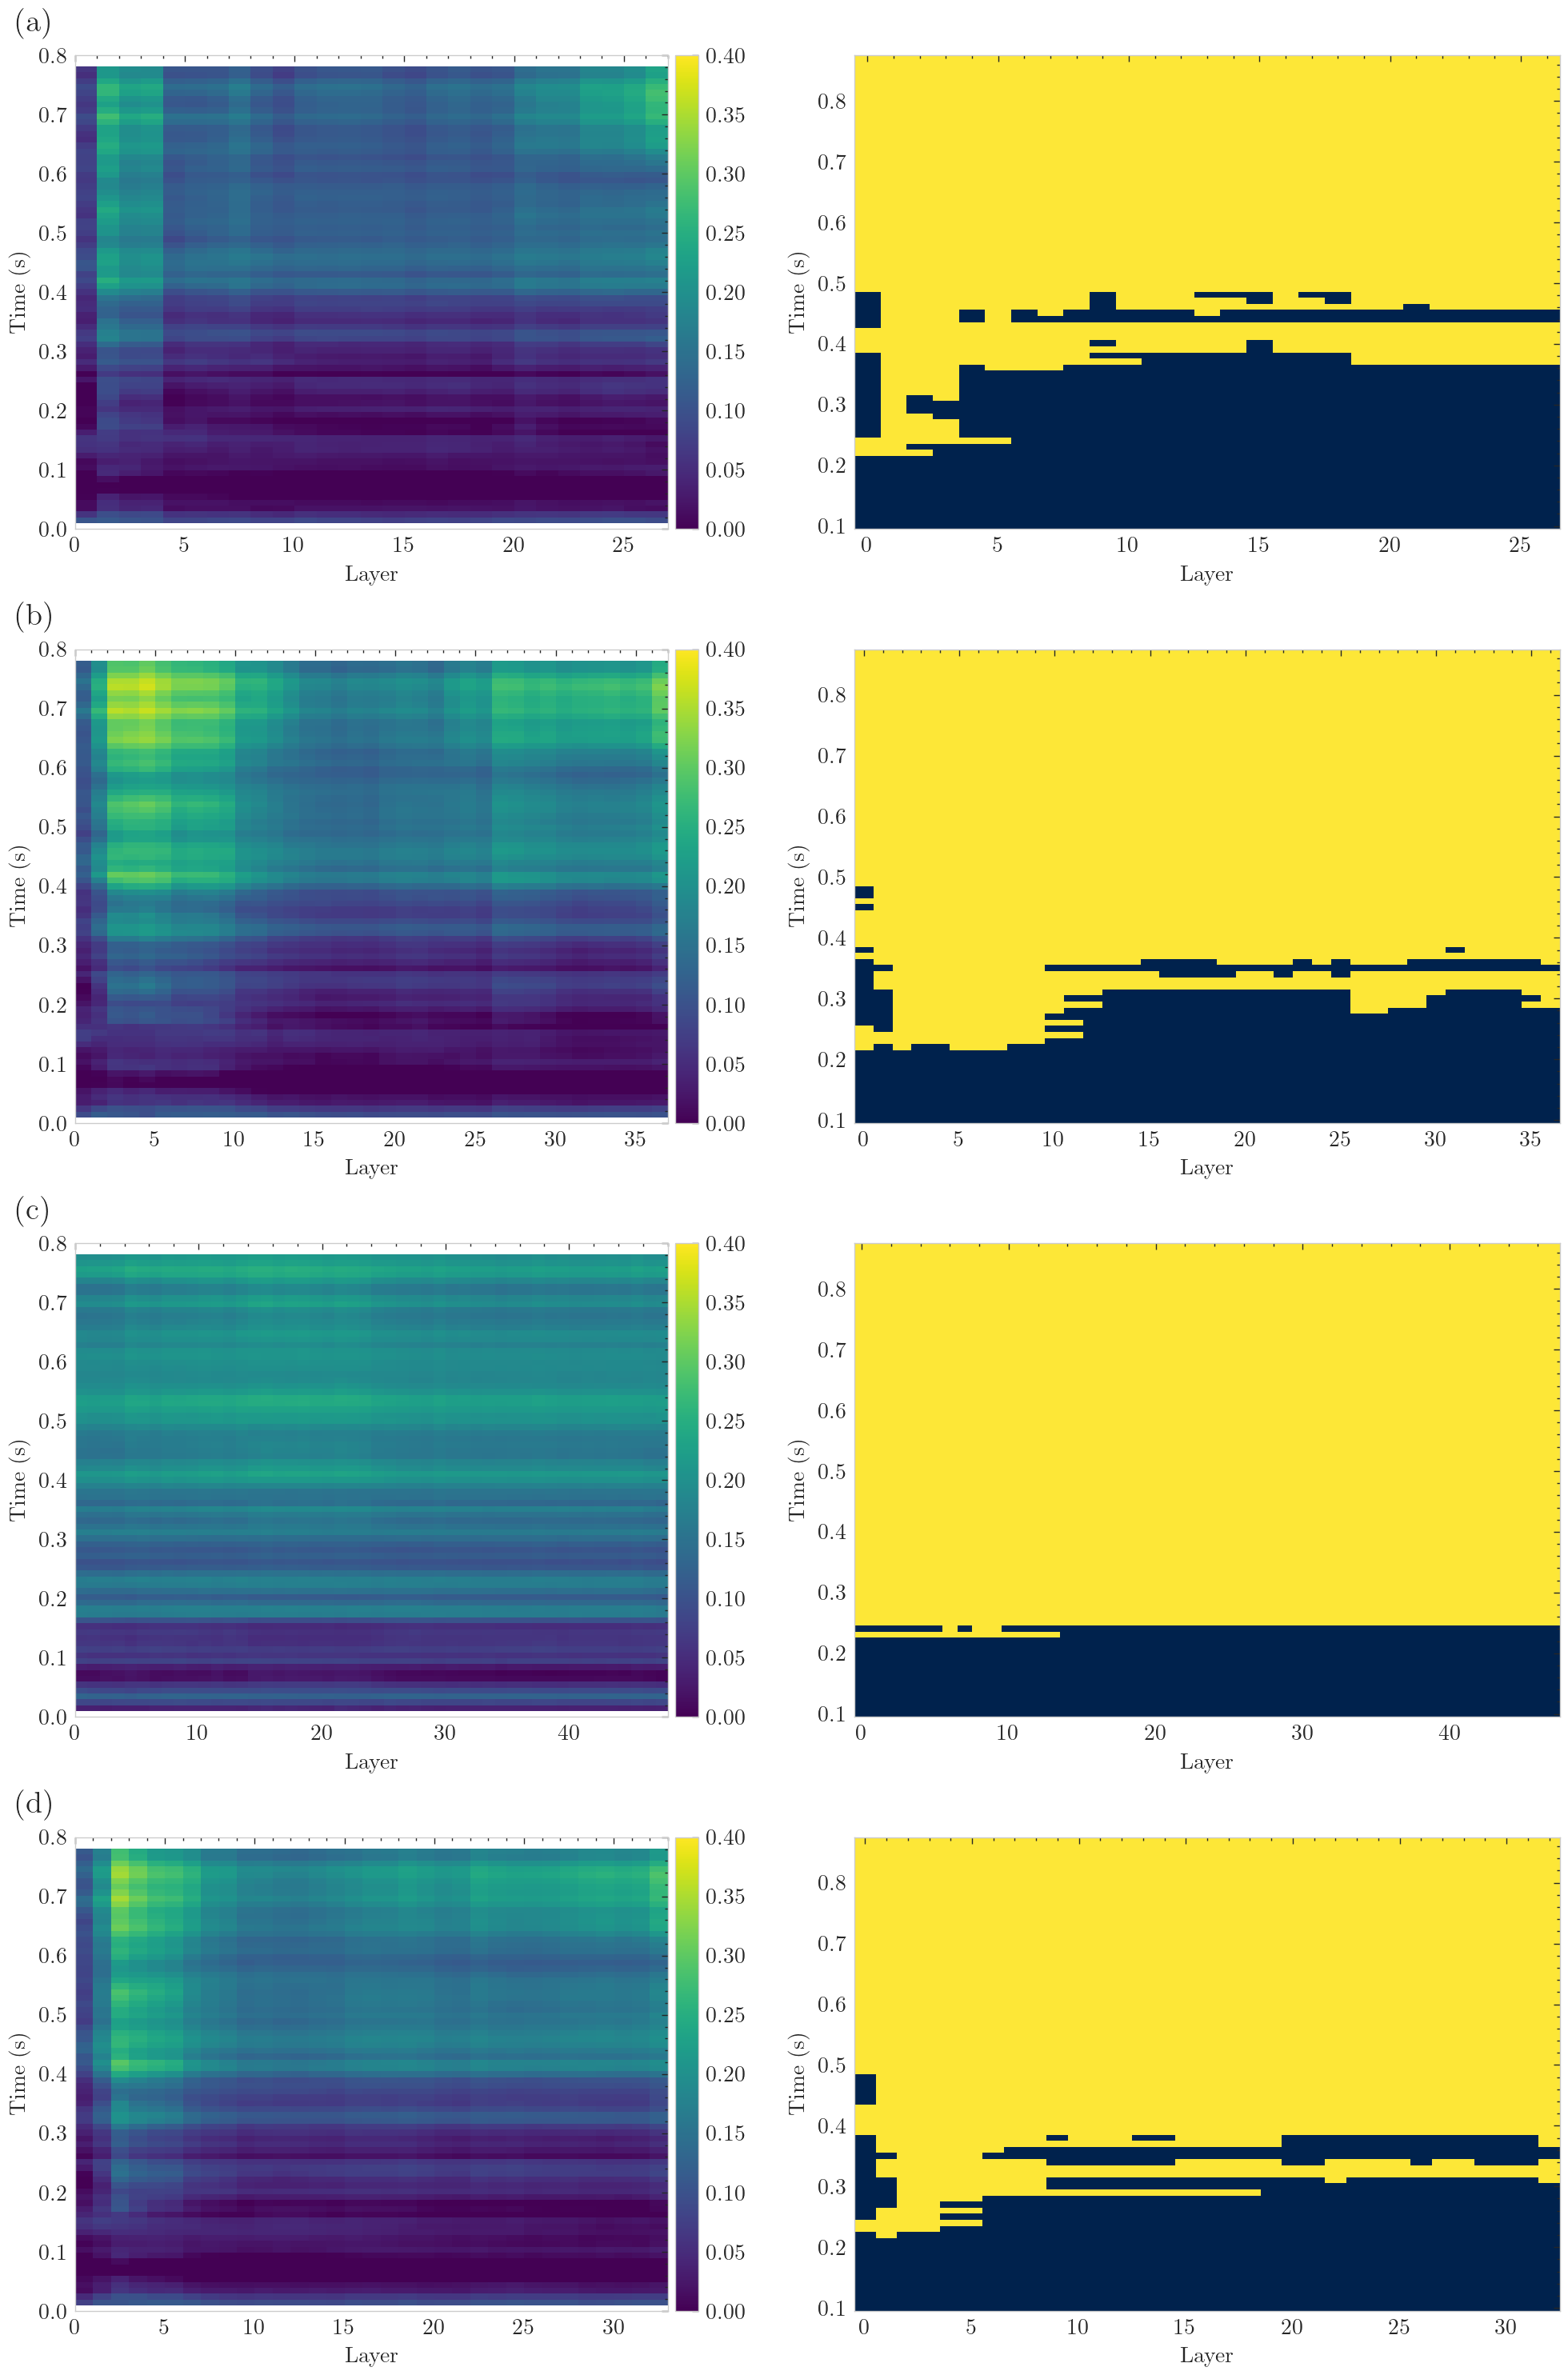

In [44]:
import string

time_centers = np.array([(t[0] + t[1]) / 2 for t in win_times])

time_tick_step = 0.1
time_ticks = np.arange(
    np.round(time_centers[0], 1),
    np.round(time_centers[-1], 1) + time_tick_step,
    time_tick_step
)

fig, axs = plt.subplots(ncols=2, nrows=4, figsize=(10, 15))
axs = axs.flatten()

i = 0


labels = string.ascii_lowercase
label_index = 0

model_rsa_dict = {}
for model, rdms in tqdm(model_rdm_dict.items(), desc="Calculating RSA"):
    try:
        print(f"Model: {model}")

        model_rsa = rsa_eeg_llm(rdms_eeg, rdms)

        model_rsa_dict[model] = rsa_eeg_llm(rdms_eeg, rdms)

        S, W, L = model_rsa.shape
        adjacency = combine_adjacency(W, L)

        T_obs, clusters, cluster_p_values, H0 = spatio_temporal_cluster_1samp_test(
            model_rsa,
            adjacency=adjacency,
            n_permutations=5000,
            threshold=None,
            tail=1,
            out_type="mask",
            verbose=True,
        )

        alpha = 0.05
        signif_mask = np.zeros((W, L), dtype=bool)

        for clu_mask, pval in zip(clusters, cluster_p_values):
            if pval < alpha:
                signif_mask |= clu_mask

        print("Significant clusters:", np.sum(cluster_p_values < alpha))


        mean_rsa = model_rsa.mean(axis=0)
        im = axs[i].imshow(
            mean_rsa,
            aspect="auto",
            origin="lower",
            extent=[
                0, mean_rsa.shape[1],
                time_centers[0], time_centers[-1]
            ],
            cmap='viridis', vmin=0, vmax=0.4
        )

        axs[i].set_ylabel("Time (s)")
        axs[i].set_yticks(time_ticks)
        axs[i].set_yticklabels([f"{t:.1f}" for t in time_ticks])
        axs[i].set_xlabel("Layer")
        axs[i].xaxis.grid(False)
        axs[i].yaxis.grid(False)

        axs[i].text(
            -0.1, 1.1,
            f"({labels[label_index]})",
            transform=axs[i].transAxes,
            fontsize=14,
            fontweight='bold',
            va='top'
        )
        label_index += 1

        fig.colorbar(im, ax=axs[i], orientation="vertical", pad=0.01)

        axs[i + 1].imshow(signif_mask, aspect="auto", origin="lower", cmap='cividis')
        axs[i + 1].set_xlabel("Layer")
        axs[i + 1].set_ylabel("Time (s)")
        axs[i + 1].set_yticklabels([f"{t:.1f}" for t in time_ticks])
        axs[i + 1].xaxis.grid(False)
        axs[i + 1].yaxis.grid(False)

        i = i + 2

    except Exception as e:
        raise e

fig.tight_layout()
plt.show()

In [ ]:
def rsa_eeg_full_llm(
    rdms_eeg: np.ndarray,   # (subjects, n_pairs)
    rdms_llm: np.ndarray,   # (layers, n_pairs)
) -> np.ndarray:

    if rdms_eeg.ndim != 2:
        raise ValueError(
            f"rdms_eeg must be 2D (S, n_pairs), got shape {rdms_eeg.shape}"
        )

    if rdms_llm.ndim != 2:
        raise ValueError(
            f"rdms_llm must be 2D (L, n_pairs), got shape {rdms_llm.shape}"
        )

    if not np.isfinite(rdms_eeg).all():
        raise ValueError("rdms_eeg contains NaN or inf")

    if not np.isfinite(rdms_llm).all():
        rdms_llm = rdms_llm[:-1, :]

    S, n_pairs_eeg = rdms_eeg.shape
    L, n_pairs_llm = rdms_llm.shape

    if n_pairs_eeg != n_pairs_llm:
        raise ValueError(
            "EEG and LLM RDMs have different number of pairs: "
            f"{n_pairs_eeg} (EEG) vs {n_pairs_llm} (LLM)"
        )

    n_cond = int((1 + np.sqrt(1 + 8 * n_pairs_eeg)) / 2)
    if n_cond * (n_cond - 1) // 2 != n_pairs_eeg:
        raise ValueError(
            f"n_pairs={n_pairs_eeg} is not a valid condensed RDM size"
        )

    rsa = np.zeros((S, L), dtype=np.float64)

    for s in range(S):
        eeg_vec = rdms_eeg[s]

        for l in range(L):
            rho, _ = spearmanr(eeg_vec, rdms_llm[l])
            rsa[s, l] = rho

    return rsa


def compute_eeg_rdms_full(
    erps_dict: dict[str, list[mne.Evoked]],
    picks: list[str] | None = None,
):

    subj_ids = list(erps_dict.keys())

    rdms = []


    for subj in subj_ids:
        evokeds = erps_dict[subj]

        if picks is not None:
            evokeds = [e.copy().pick(picks) for e in evokeds]

        data = np.stack([e.data for e in evokeds], axis=0)
        n_cond, n_ch, n_t = data.shape
        X = data.reshape(n_cond, n_ch * n_t)
        X = (X - X.mean(axis=0)) / X.std(axis=0)
        rdm = mne_rsa.compute_rdm(
            X,
            metric="correlation",
        )
        rdms.append(rdm)

    rdms = np.asarray(rdms)
    return rdms, subj_ids

rdms_eeg_full, subj_ids = compute_eeg_rdms_full(erps_dict)
print("FUll eeg rdm complete")

Static RSA:  50%|█████     | 2/4 [00:00<00:00, 11.40it/s]

Model: ai-sage/GigaChat3-10B-A1.8B-base
Model: Qwen/Qwen3-8B
Model: google/gemma-3-12b-pt


Static RSA: 100%|██████████| 4/4 [00:00<00:00,  9.82it/s]

Model: meta-llama/Meta-Llama-3-8B


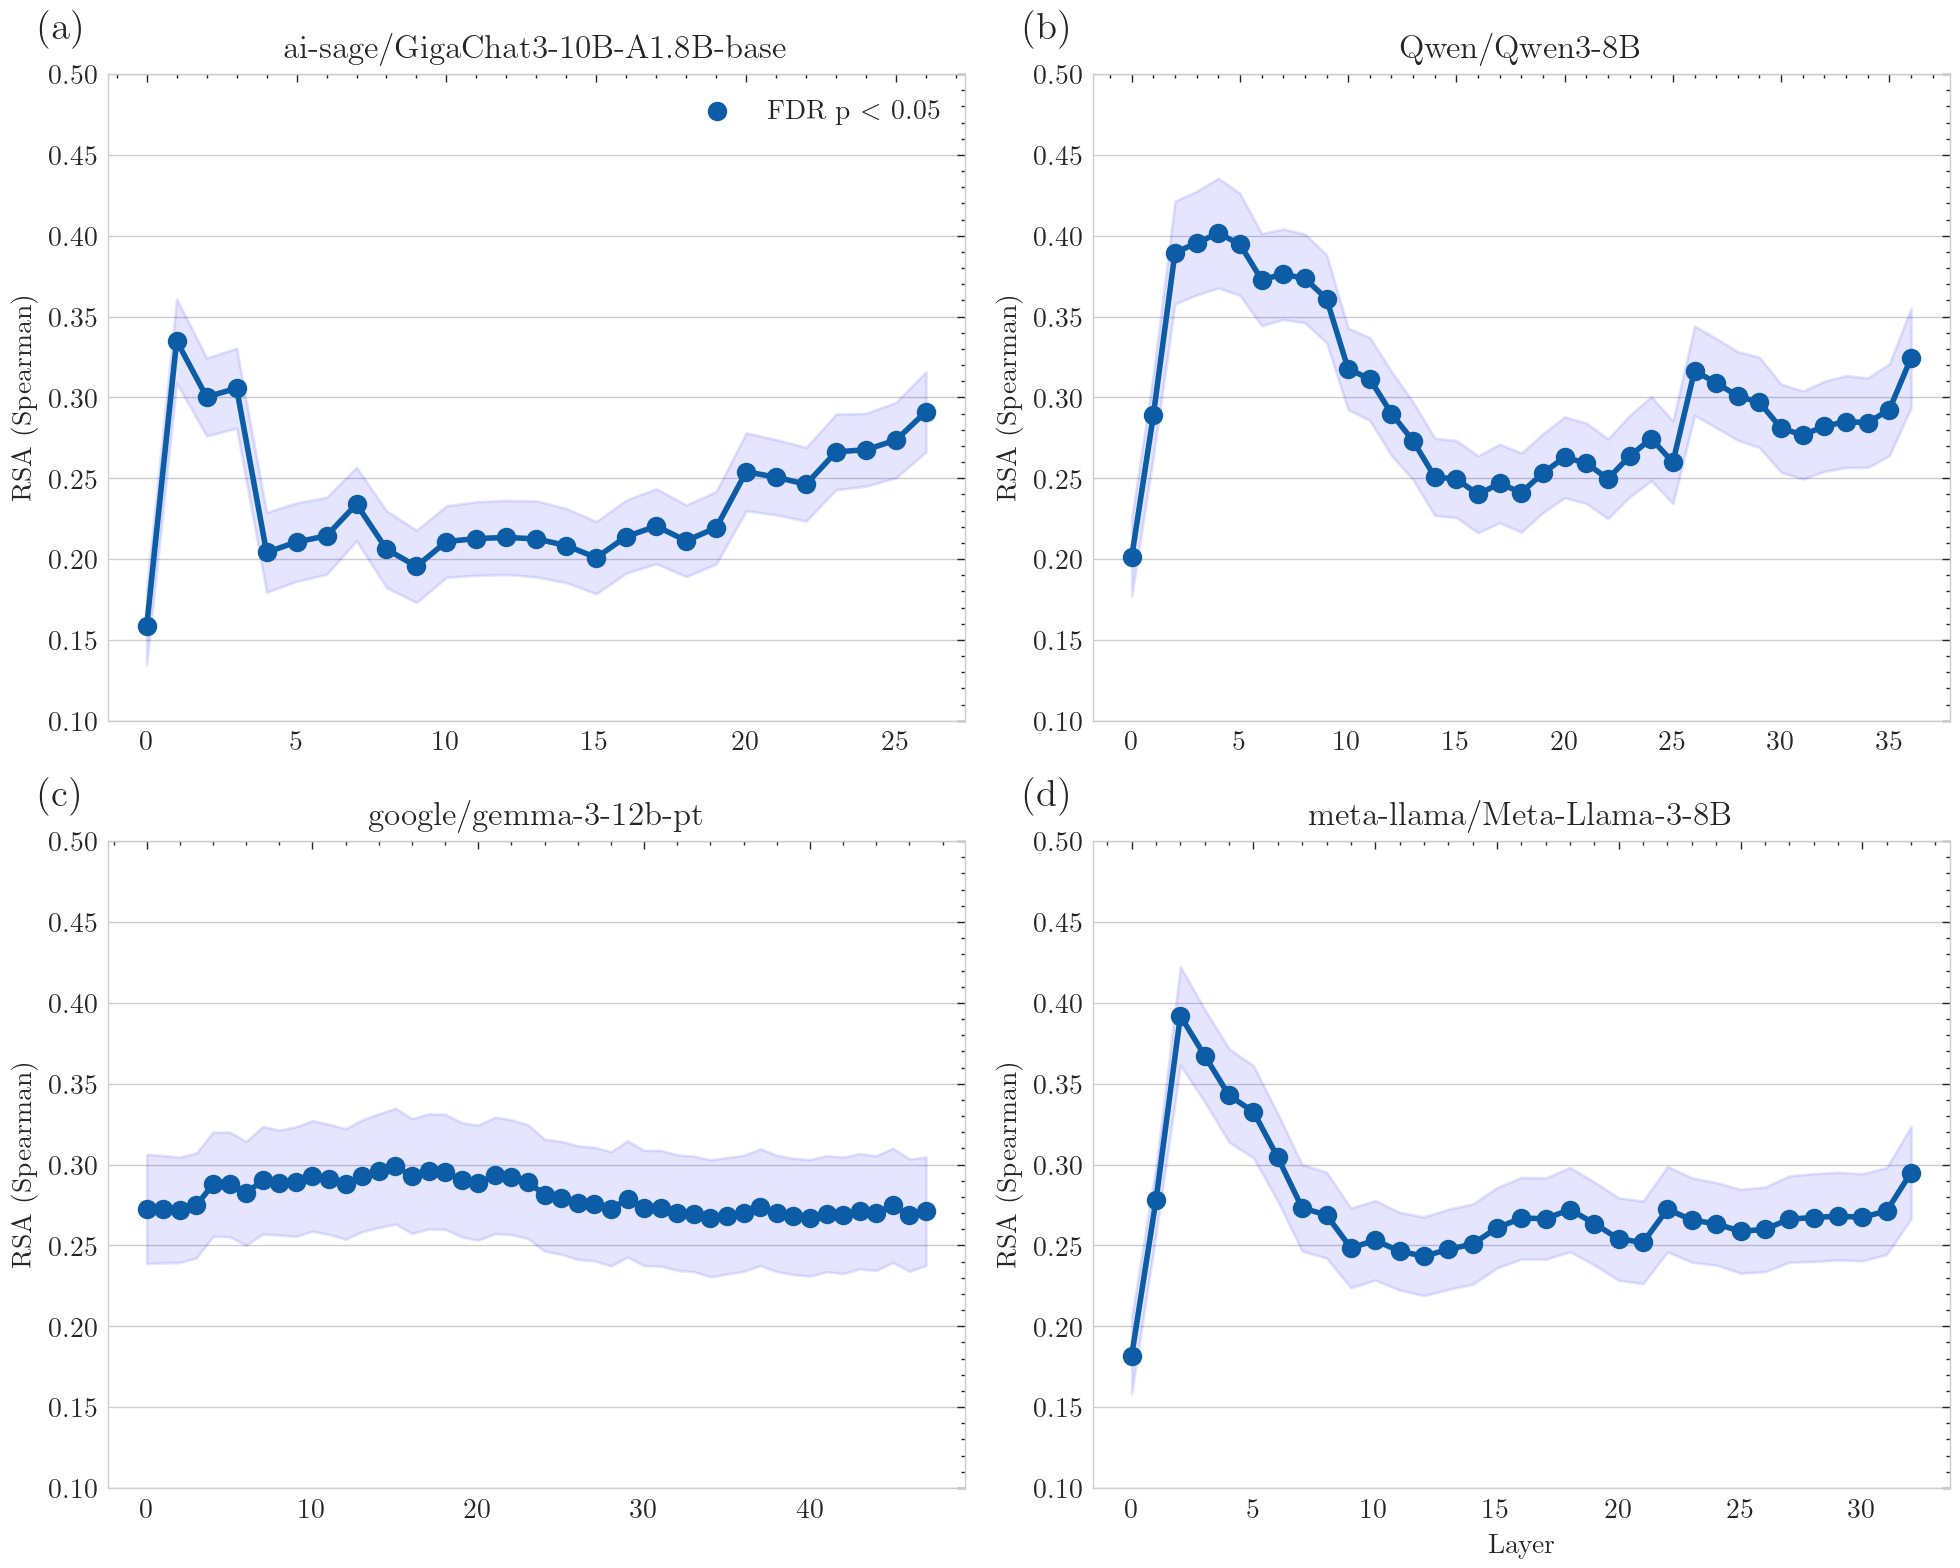

In [85]:
model_eeg_full_rsa_dict = {}
for model, rdms_llm in tqdm(model_rdm_dict.items(), desc="Static RSA"):
    print(f"Model: {model}")

    model_rsa = rsa_eeg_full_llm(
        rdms_eeg=rdms_eeg_full,
        rdms_llm=rdms_llm,
    )

    model_eeg_full_rsa_dict[model] = model_rsa


stats_dict = {}

alpha = 0.05

for model, rsa in model_eeg_full_rsa_dict.items():

    S, L = rsa.shape

    tvals = np.zeros(L)
    pvals = np.zeros(L)

    for l in range(L):
        t, p = ttest_1samp(rsa[:, l], 0.0)
        tvals[l] = t
        pvals[l] = p

    reject, pvals_fdr = fdrcorrection(pvals, alpha=alpha)

    stats_dict[model] = {
        "tvals": tvals,
        "pvals": pvals,
        "pvals_fdr": pvals_fdr,
        "significant": reject,
    }


fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10, 8))

axs = axs.flatten()

if len(model_eeg_full_rsa_dict) == 1:
    axs = [axs]

labels = list("abcdefghijklmnopqrstuvwxyz")
label_index = 0

for ax, (model, rsa) in zip(axs, model_eeg_full_rsa_dict.items()):

    mean_rsa = rsa.mean(axis=0)                       # (L,)
    sem_rsa = rsa.std(axis=0) / np.sqrt(rsa.shape[0]) # (L,)
    layers = np.arange(len(mean_rsa))

    ax.plot(layers, mean_rsa, lw=2)

    ax.fill_between(
        layers,
        mean_rsa - sem_rsa,
        mean_rsa + sem_rsa,
        alpha=0.1,
        color="blue",
    )


    signif = stats_dict[model]["significant"]
    ax.scatter(
        layers[signif],
        mean_rsa[signif],
        zorder=5,
        label="FDR p $<$ 0.05" if label_index == 0 else None,
    )

    ax.set_ylabel("RSA (Spearman)")
    ax.set_title(model)
    ax.xaxis.grid(False)

    ax.set_ylim(0.1, 0.5)
    ax.xaxis.grid(False)

    ax.text(
        -0.08, 1.1,
        f"({labels[label_index]})",
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
    )

    label_index += 1

axs[-1].set_xlabel("Layer")

if len(model_eeg_full_rsa_dict) > 1:
    axs[0].legend(loc="upper right")

fig.tight_layout()
plt.show()


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

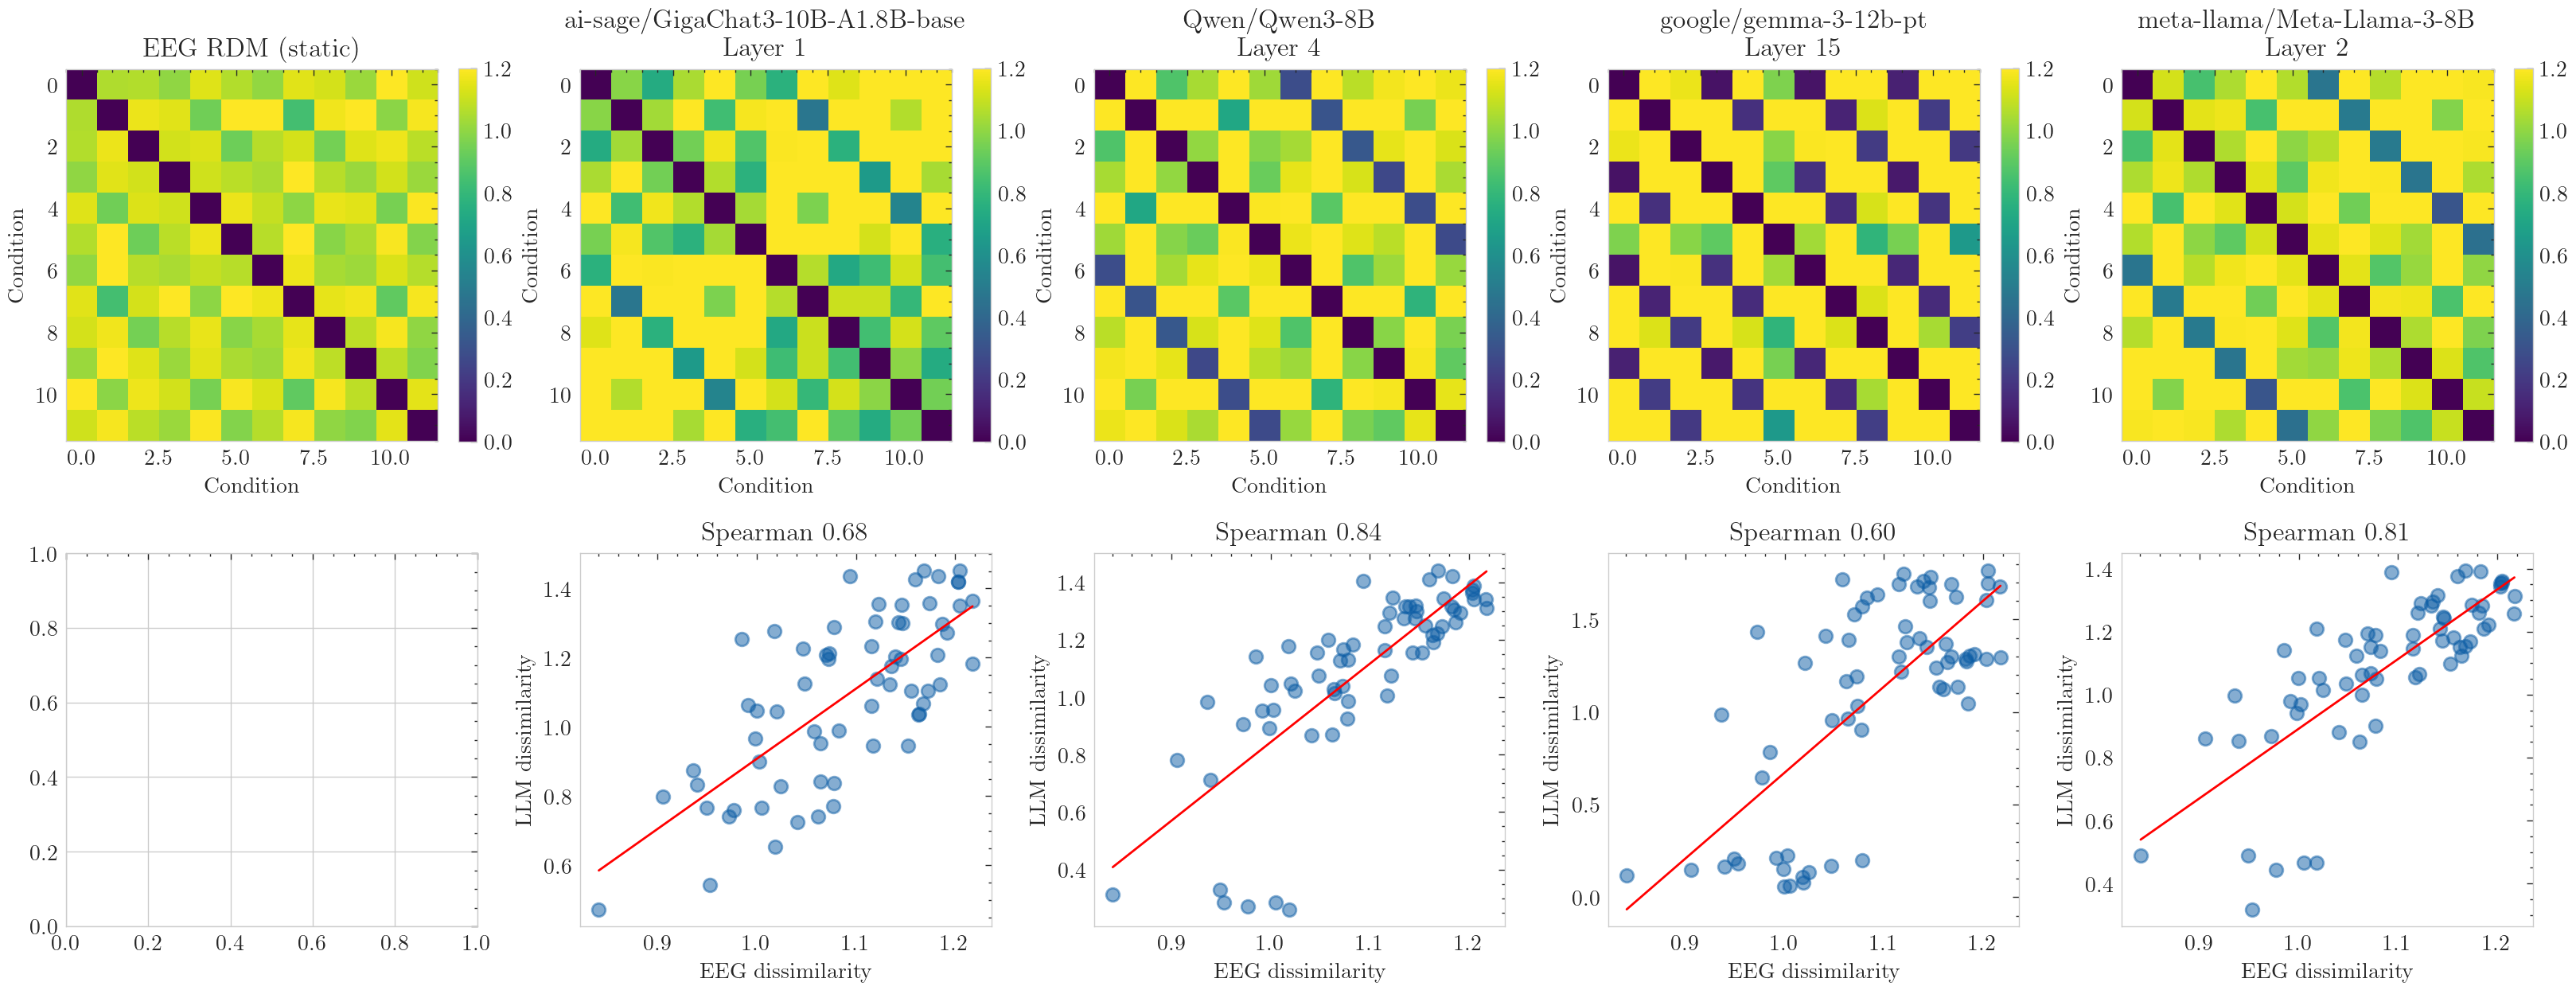

In [99]:


eeg_rdm_mean = rdms_eeg_full.mean(axis=0)
eeg_rdm_sq = squareform(eeg_rdm_mean)

model_names = list(model_eeg_full_rsa_dict.keys())
n_models = len(model_names)

vmin, vmax = 0.0, 1.2

fig, axs = plt.subplots(
    2,
    n_models + 1,
    figsize=(4 * (n_models + 1), 7),
    gridspec_kw={"wspace": 0.25, "hspace": 0.3},
)

im = axs[0, 0].imshow(eeg_rdm_sq, cmap="viridis", vmin=vmin, vmax=vmax)
axs[0, 0].set_title("EEG RDM (static)")
axs[0, 0].set_xlabel("Condition")
axs[0, 0].set_ylabel("Condition")
axs[0, 0].grid(False)

fig.colorbar(im, ax=axs[0, 0], fraction=0.046)

for i, model_name in enumerate(model_names, start=1):

    rsa_static = model_eeg_full_rsa_dict[model_name]   # (S, L)
    rdms_llm = model_rdm_dict[model_name]              # (L, n_pairs)

    mean_rsa = rsa_static.mean(axis=0)
    peak_layer = np.argmax(mean_rsa)

    llm_rdm_peak = rdms_llm[peak_layer]
    llm_rdm_sq = squareform(llm_rdm_peak)

    im = axs[0, i].imshow(llm_rdm_sq, cmap="viridis", vmin=vmin, vmax=vmax)
    axs[0, i].set_title(f"{model_name}\nLayer {peak_layer}")
    axs[0, i].set_xlabel("Condition")
    axs[0, i].set_ylabel("Condition")
    axs[0, i].grid(False)

    fig.colorbar(im, ax=axs[0, i], fraction=0.046)

    axs[1, i].scatter(eeg_rdm_mean, llm_rdm_peak, alpha=0.5)
    axs[1, i].set_xlabel("EEG dissimilarity")
    axs[1, i].set_ylabel("LLM dissimilarity")
    axs[1, i].grid(False)

    rho, p = spearmanr(eeg_rdm_mean, llm_rdm_peak)
    axs[1, i].set_title(f"Spearman {rho:.2f}")

    coef = np.polyfit(eeg_rdm_mean, llm_rdm_peak, 1)
    x = np.linspace(eeg_rdm_mean.min(), eeg_rdm_mean.max(), 100)
    axs[1, i].plot(x, coef[0] * x + coef[1], color="red")
